# Importing the Dataset

In [2]:
import pandas as pd
df=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
from langchain.chains import ConversationChain
from langchain.memory import ConversationBufferMemory
from langchain.llms import OpenAI

# HR Chatbot Class Definition
class HRChatbot:
    def __init__(self, df):
        self.df = df
        os.environ["OPENAI_API_KEY"] = "your-openai-api-key"  # Replace with your key
        self.llm = OpenAI(temperature=0.7)
        self.memory = ConversationBufferMemory()
        self.conversation = ConversationChain(
            llm=self.llm,
            memory=self.memory,
            verbose=True
        )
        
    def get_attrition_stats(self):
        """Helper method to get stats for chatbot responses"""
        attrition_rate = (self.df['Attrition'].value_counts()['Yes'] / len(self.df)) * 100
        dept_attrition = self.df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()['Yes'] * 100
        return {
            "overall_rate": round(attrition_rate, 1),
            "by_department": dept_attrition.round(1).to_dict()
        }
    
    def get_response(self, user_input):
        """Main method to get chatbot response"""
        # Check if question is about attrition
        if "attrition" in user_input.lower():
            stats = self.get_attrition_stats()
            prompt = f"""
            The user asked: {user_input}
            
            Here are the current attrition statistics:
            - Overall attrition rate: {stats['overall_rate']}%
            - By department: {stats['by_department']}
            
            Provide a helpful HR response analyzing this data.
            """
            return self.conversation.predict(input=prompt)
        else:
            return self.conversation.predict(input=user_input)

# Analyzing the dataset

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80.0,0,8,0,1,6.0,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80.0,1,10,3,3,10.0,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80.0,0,7,3,3,0.0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80.0,0,8,3,3,8.0,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80.0,1,6,3,3,2.0,2,2,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   object 
 8   EmployeeCount             1470 non-null   int64  
 9   EmployeeNumber            1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [6]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     1
JobSatisfaction             1
MaritalStatus               0
MonthlyIncome               4
MonthlyRate                 3
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           1
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               1
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              2
YearsInCurrentRole          0
YearsSince

# Plotting the Insights

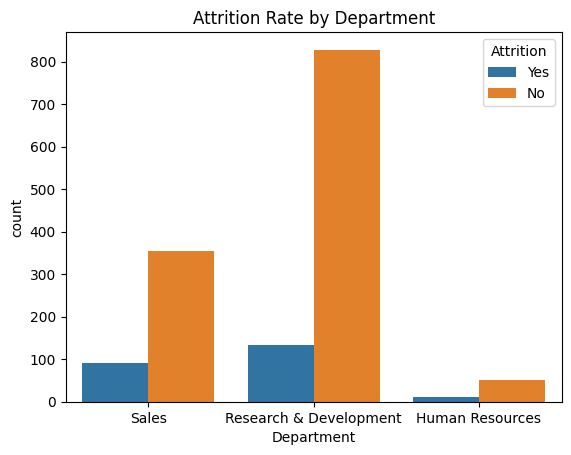

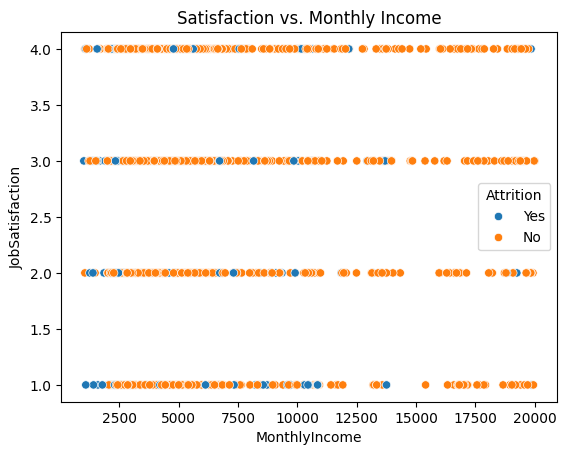

Attrition
No     1233
Yes     237
Name: count, dtype: int64


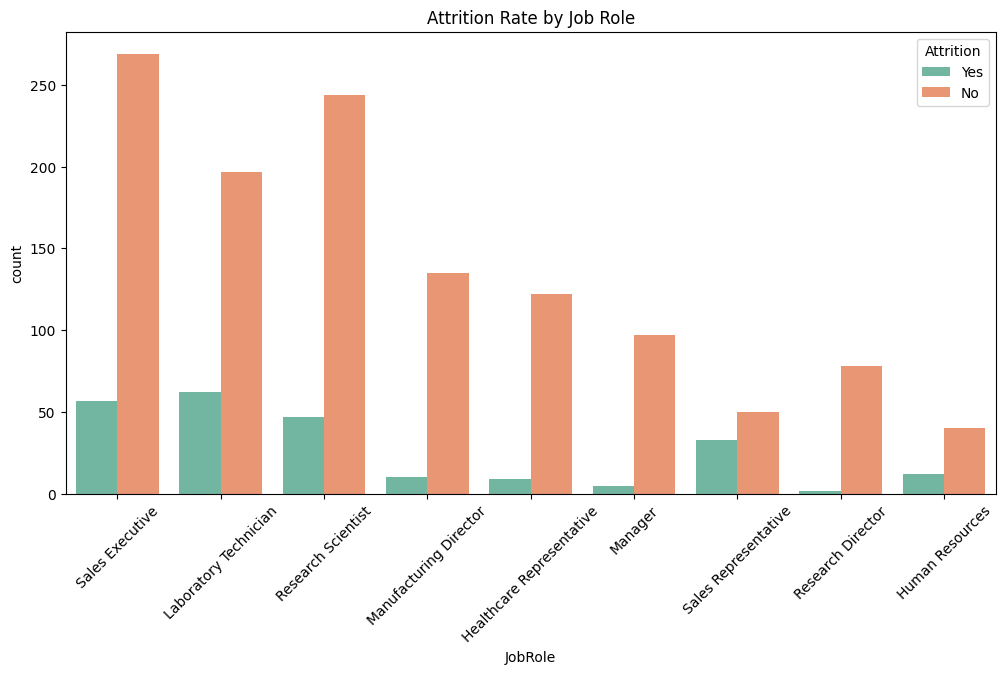

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='Department', hue='Attrition')
plt.title("Attrition Rate by Department")
plt.show()

sns.scatterplot(data=df, x='MonthlyIncome', y='JobSatisfaction', hue='Attrition')
plt.title("Satisfaction vs. Monthly Income")
plt.show()

print(df['Attrition'].value_counts())

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='JobRole', hue='Attrition', palette='Set2')
plt.title("Attrition Rate by Job Role")
plt.xticks(rotation=45)
plt.show()


# Handling the missing values

In [10]:
numerical_columns = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
                     'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears',
                     'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole',
                     'YearsSinceLastPromotion', 'YearsWithCurrManager','JobSatisfaction','StandardHours']
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

categorical_columns = ['Attrition', 'BusinessTravel', 'Department', 'EducationField',
                       'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInC

# Converting the Categorical data into numerical data

In [12]:
import sklearn as sk
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [13]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = ['Attrition', 'BusinessTravel', 'Department', 'EducationField',
                       'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

label_encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

print(df.head())


   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   41          1               2       1102           2                 1   
1   49          0               1        279           1                 8   
2   37          1               2       1373           1                 2   
3   33          0               1       1392           1                 3   
4   27          0               2        591           1                 2   

   Education  EducationField  EmployeeCount  EmployeeNumber  ...  \
0          2               1              1               1  ...   
1          1               1              1               2  ...   
2          2               4              1               4  ...   
3          4               1              1               5  ...   
4          1               3              1               7  ...   

   RelationshipSatisfaction  StandardHours  StockOptionLevel  \
0                         1           80.0                

# Dropping unnecessary columns for better understanding and working

In [15]:
df = df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1)


In [16]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

# Normalizing the data in common scale

In [18]:
scaler = StandardScaler()
numerical_features = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
df[numerical_features] = scaler.fit_transform(df[numerical_features])

In [19]:
print(df.head())

        Age  Attrition  BusinessTravel  DailyRate  Department  \
0  0.446350          1               2   0.742527           2   
1  1.322365          0               1  -1.297775           1   
2  0.008343          1               2   1.414363           1   
3 -0.429664          0               1   1.461466           1   
4 -1.086676          0               2  -0.524295           1   

   DistanceFromHome  Education  EducationField  EnvironmentSatisfaction  \
0         -1.010909          2               1                        2   
1         -0.147150          1               1                        3   
2         -0.887515          2               4                        4   
3         -0.764121          4               1                        4   
4         -0.887515          1               3                        1   

   Gender  ...  PerformanceRating  RelationshipSatisfaction  StockOptionLevel  \
0       0  ...                  3                         1                 0

# ML model for prediction of the attrition

In [21]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score


In [22]:
 X=df.drop('Attrition',axis=1)
y=df['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [23]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42)
}

accuracies = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    accuracies[model_name] = accuracy

    print(f"Model: {model_name}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy:.4f}")
    print("-" * 50)


Model: Logistic Regression
Confusion Matrix:
[[368  12]
 [ 46  15]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       380
           1       0.56      0.25      0.34        61

    accuracy                           0.87       441
   macro avg       0.72      0.61      0.63       441
weighted avg       0.84      0.87      0.85       441

Accuracy: 0.8685
--------------------------------------------------
Model: Decision Tree
Confusion Matrix:
[[319  61]
 [ 39  22]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.86       380
           1       0.27      0.36      0.31        61

    accuracy                           0.77       441
   macro avg       0.58      0.60      0.59       441
weighted avg       0.80      0.77      0.79       441

Accuracy: 0.7732
--------------------------------------------------
Model: Random Forest
Confusion Mat

In [24]:
best_model = max(accuracies, key=accuracies.get)
best_accuracy = accuracies[best_model]

print(f"\n***** Best Model: {best_model} with Accuracy: {best_accuracy:.4f} *****")



***** Best Model: Gradient Boosting with Accuracy: 0.8753 *****


In [25]:
import pickle

best_model_object = models[best_model] 
pickle.dump(best_model_object, open('attrition_model.pkl', 'wb'))
print(f"Best model ({best_model}) saved successfully as 'attrition_model.pkl'!")


Best model (Gradient Boosting) saved successfully as 'attrition_model.pkl'!


In [26]:
y_numeric = [1 if label in ['Yes', '1', 1] else 0 for label in y]
all_y_pred_numeric = [1 if label in ['Yes', '1', 1] else 0 for label in models[best_model].predict(X)]

total_employees = len(y_numeric)
actual_left = sum(y_numeric)
actual_stayed = total_employees - actual_left
predicted_left = sum(all_y_pred_numeric)
predicted_stayed = total_employees - predicted_left

all_cm = confusion_matrix(y_numeric, all_y_pred_numeric)
tn, fp, fn, tp = all_cm.ravel()

actual_attrition_rate = actual_left / total_employees
predicted_attrition_rate = predicted_left / total_employees

print("\nOverall Attrition Insights (Entire Dataset):")
print(f"Total Employees: {total_employees}")
print(f"Actual Employees who Left: {actual_left}")
print(f"Actual Employees who Stayed: {actual_stayed}")
print(f"Predicted Employees at Risk of Leaving (May Leave in Future): {predicted_left}")
print(f"Correctly Predicted Attrition (True Positives): {tp}")
print(f"Potential False Alarms (Predicted to Leave but Stayed): {fp}")
print(f"Actual Attrition Rate: {actual_attrition_rate:.4%}")
print(f"Predicted Attrition Rate: {predicted_attrition_rate:.4%}")
print("-" * 50)



Overall Attrition Insights (Entire Dataset):
Total Employees: 1470
Actual Employees who Left: 237
Actual Employees who Stayed: 1233
Predicted Employees at Risk of Leaving (May Leave in Future): 166
Correctly Predicted Attrition (True Positives): 153
Potential False Alarms (Predicted to Leave but Stayed): 13
Actual Attrition Rate: 16.1224%
Predicted Attrition Rate: 11.2925%
--------------------------------------------------


# Promotion Prediction

In [28]:
import numpy as np

df['PromotionEligibility'] = np.where((df['JobSatisfaction'] >= 3) & (df['PerformanceRating'] >= 3) & (df['YearsAtCompany'] >= 3), 1, 0)

df['PromotionEligibility'] = df['PromotionEligibility'].replace({0: "Employees Not Eligible", 1: "Employees Eligible"})


print("Promotion Eligibility Distribution:\n", df['PromotionEligibility'].value_counts())

X = df.drop(columns=['PromotionEligibility'])
y = df['PromotionEligibility']

X = X.select_dtypes(include=[np.number])


Promotion Eligibility Distribution:
 PromotionEligibility
Employees Not Eligible    1457
Employees Eligible          13
Name: count, dtype: int64


## Retarining Attrition Model for Selected Features

In [30]:
try:
    with open('attrition_model.pkl', 'rb') as f:
        original_model = pickle.load(f)
    print("Original model loaded successfully")
except FileNotFoundError:
    print("Original model not found - train it first")
    exit()

Original model loaded successfully


In [31]:
SELECTED_FEATURES = ['MonthlyIncome', 'Age', 'JobSatisfaction','OverTime', 'YearsAtCompany']
TARGET = 'Attrition' 

In [32]:
X_simple = df[SELECTED_FEATURES]
y_simple = df[TARGET]

In [33]:
simple_model = GradientBoostingClassifier(n_estimators=100).fit(X_simple, y_simple)

X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

In [34]:
simple_model.fit(X_train, y_train)
preds = simple_model.predict(X_test)
print(f"Simplified model accuracy: {accuracy_score(y_test, preds):.2f}")

with open('attrition_model_simplified.pkl', 'wb') as f:
    pickle.dump(simple_model, f)
print("Simplified model saved successfully")

if hasattr(original_model, 'feature_names_in_'):
    original_acc = accuracy_score(y_test,original_model.predict(df.loc[X_test.index, original_model.feature_names_in_]))
    print(f"Original model accuracy: {original_acc:.2f}")
    print(f"Accuracy difference: {original_acc - accuracy_score(y_test, preds):.2f}")

def predict_attrition_simple(input_data):
    input_df = pd.DataFrame([input_data])[SELECTED_FEATURES]
    if 'OverTime' in input_df.columns:
        input_df['OverTime'] = input_df['OverTime'].map({'Yes': 1, 'No': 0})
    return simple_model.predict_proba(input_df)[0][1]  


Simplified model accuracy: 0.86
Simplified model saved successfully
Original model accuracy: 0.87
Accuracy difference: 0.01
